# Social Network Community Detection

**Objective:** Discover connected communities and bridge accounts from an interaction graph using spectral clustering.

A deterministic interaction graph demonstrates label-free community discovery. Hidden generator communities are used only after clustering as a diagnostic.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Generate a community-structured interaction graph


In [2]:
N_COMMUNITIES = 4
NODES_PER_COMMUNITY = 45
N_NODES = N_COMMUNITIES * NODES_PER_COMMUNITY
generator_community = np.repeat(np.arange(N_COMMUNITIES), NODES_PER_COMMUNITY)
adjacency = np.zeros((N_NODES, N_NODES), dtype=float)
for i in range(N_NODES):
    for j in range(i + 1, N_NODES):
        same = generator_community[i] == generator_community[j]
        probability = 0.18 if same else 0.012
        if rng.random() < probability:
            weight = float(rng.integers(1, 8) if same else rng.integers(1, 4))
            adjacency[i, j] = adjacency[j, i] = weight
np.fill_diagonal(adjacency, 1e-6)
degree = (adjacency > 0).sum(axis=1) - 1
print(f"Nodes: {N_NODES} | undirected edges: {int(np.count_nonzero(np.triu(adjacency, 1)))}")
display(pd.Series(degree).describe().round(3).to_frame("degree"))


Nodes: 180 | undirected edges: 854


,degree
count,180.000
mean,9.489
std,2.964
min,2.000
25%,7.000
50%,9.000
75%,11.000
max,20.000


## 3. Spectral community detection


In [3]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score

selection = []
degree_matrix = np.diag(adjacency.sum(axis=1))
laplacian = degree_matrix - adjacency
eigenvalues = np.sort(np.linalg.eigvalsh(laplacian))
for k in range(2, 7):
    labels = SpectralClustering(n_clusters=k, affinity="precomputed", assign_labels="kmeans", random_state=RANDOM_STATE).fit_predict(adjacency)
    selection.append({"k": k, "adjacency_profile_silhouette": silhouette_score(adjacency, labels, metric="cosine")})
selection = pd.DataFrame(selection)
display(selection.round(4))
best_k = int(selection.loc[selection["adjacency_profile_silhouette"].idxmax(), "k"])
labels = SpectralClustering(n_clusters=best_k, affinity="precomputed", assign_labels="kmeans", random_state=RANDOM_STATE).fit_predict(adjacency)
print(f"Selected k={best_k}; retrospective ARI={adjusted_rand_score(generator_community, labels):.4f}")
print("Smallest Laplacian eigenvalues:", np.round(eigenvalues[:8], 4))


Selected k=4; retrospective ARI=1.0000
Smallest Laplacian eigenvalues: [-0.      3.3044  3.3339  3.7947  5.6483  9.1255  9.8111 10.3939]


,k,adjacency_profile_silhouette
0,2,0.0642
1,3,0.0936
2,4,0.1197
3,5,0.1067
4,6,0.0960


## 4. Community profile and bridge-account analysis


In [4]:
nodes = pd.DataFrame({"node_id": [f"member-{i:03d}" for i in range(N_NODES)], "community": labels, "degree": degree})
external_connections = []
for node in range(N_NODES):
    neighbours = np.flatnonzero(adjacency[node] > 0)
    neighbours = neighbours[neighbours != node]
    external_connections.append(int(np.sum(labels[neighbours] != labels[node])))
nodes["external_connections"] = external_connections
nodes["bridge_ratio"] = nodes["external_connections"] / nodes["degree"].clip(lower=1)
display(nodes.groupby("community").agg(nodes=("node_id", "count"), mean_degree=("degree", "mean"), mean_bridge_ratio=("bridge_ratio", "mean")).round(3))
display(nodes.sort_values(["external_connections", "bridge_ratio"], ascending=False).head(12))


,nodes,mean_degree,mean_bridge_ratio
community,,,
0,45,8.578,0.176
1,45,10.044,0.157
2,45,9.200,0.178
3,45,10.133,0.143


,node_id,community,degree,external_connections,bridge_ratio
132,member-132,3,20,6,0.300000
68,member-068,0,10,5,0.500000
167,member-167,1,11,5,0.454545
153,member-153,1,12,5,0.416667
43,member-043,2,7,4,0.571429
175,member-175,1,9,4,0.444444
16,member-016,2,11,4,0.363636
19,member-019,2,11,4,0.363636
56,member-056,0,11,4,0.363636
91,member-091,3,13,4,0.307692


## 5. Lightweight graph visualization


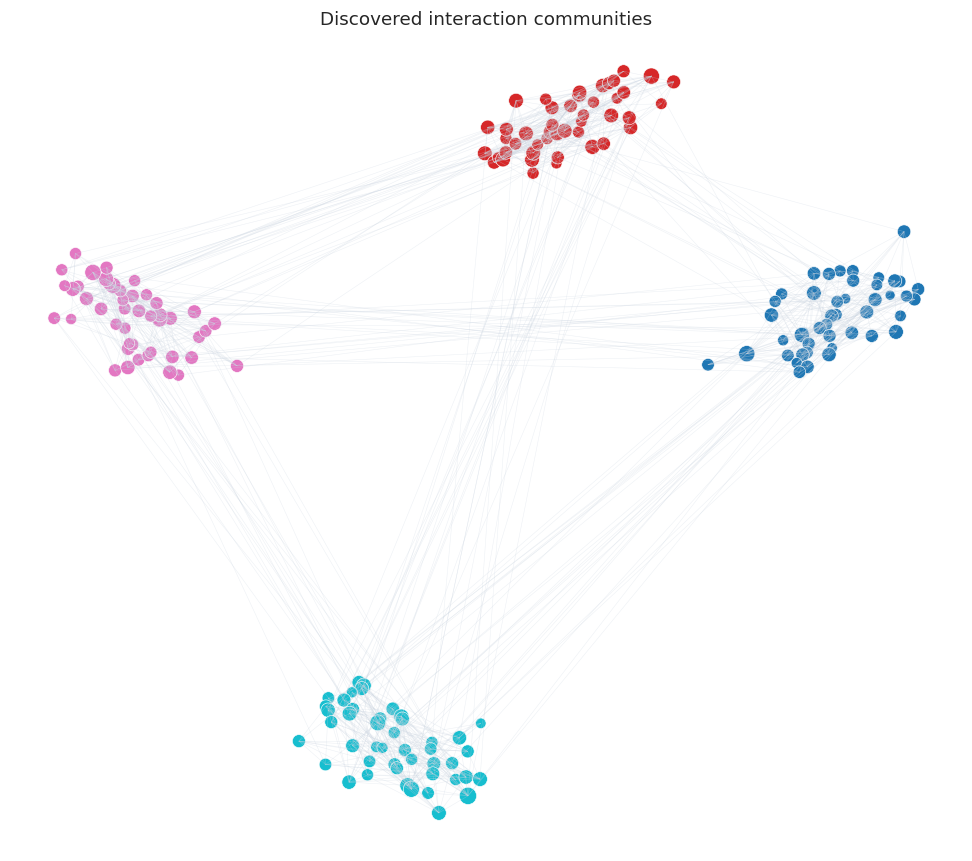

In [5]:
angles = np.linspace(0, 2 * np.pi, N_NODES, endpoint=False)
community_angles = 2 * np.pi * labels / max(best_k, 1)
radius = 1 + 0.22 * rng.normal(size=N_NODES)
x = 3.3 * np.cos(community_angles) + radius * np.cos(angles)
y = 3.3 * np.sin(community_angles) + radius * np.sin(angles)
plt.figure(figsize=(9, 8))
for i, j in zip(*np.nonzero(np.triu(adjacency, 1))):
    plt.plot([x[i], x[j]], [y[i], y[j]], color="#cbd5e1", linewidth=0.35, alpha=0.35)
plt.scatter(x, y, c=labels, cmap="tab10", s=28 + 5 * degree, edgecolor="white", linewidth=0.4)
plt.title("Discovered interaction communities")
plt.axis("off")
plt.tight_layout()
plt.show()


## 6. Findings and limitations

- Community labels describe network structure, not identity, intent, or influence.
- Bridge ratios surface cross-community connectors but should not drive moderation or access decisions.
- Production graphs require temporal stability checks, bot filtering, privacy controls, and stakeholder review.
